<a href="https://colab.research.google.com/github/vanajakodi0-beep/BlackFridaySalesPrediction/blob/main/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [3]:
# Load Dataset
df = pd.read_csv("/content/amazon_ecommerce_1M.csv")


/tmp/ipykernel_6430/3228836369.py:2: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/amazon_ecommerce_1M.csv")


In [4]:
# Display Dataset

print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

   user_id product_id     category subcategory    brand     price  discount  \
0  U356787     P39256  Electronics      Mobile      H&M  33090.51     10.46   
1  U198246     P38657       Sports     Outdoor  Samsung   9368.97      5.32   
2  U539898     P38893       Sports     Fitness      H&M  14756.85     26.00   
3  U325772     P54118       Beauty      Makeup     Sony    668.83     24.81   
4  U865179     P70217         Home       Decor     Sony  10881.29     48.63   

   final_price  rating  review_count  stock seller_id  seller_rating  \
0     29629.31     4.9          43.0   71.0     S2679            4.3   
1      8870.73     3.9          13.0  119.0     S9279            4.9   
2     10919.43     4.2          46.0  229.0     S5557            4.9   
3       502.91     3.8           6.0   52.0     S2519            3.1   
4      5589.58     4.0          48.0  274.0     S3045            2.6   

  purchase_date  shipping_time_days   location      device payment_method  \
0    2025-03-04

In [6]:
# DATA CLEANING
print("\nMissing Values")
print(df.isnull().sum())

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Fill missing numeric values
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Convert purchase date into datetime first
# Use errors='coerce' to turn unparseable dates (like initial NaNs) into NaT
df["purchase_date"] = pd.to_datetime(df["purchase_date"], errors='coerce')

# Fill missing categorical values (excluding the now datetime 'purchase_date')
categorical_cols = df.select_dtypes(include='object').columns
df[categorical_cols] = df[categorical_cols].fillna("Unknown")

print("\nDataset Shape After Cleaning:")
print(df.shape)


Missing Values
user_id               0
product_id            0
category              0
subcategory           0
brand                 0
price                 0
discount              0
final_price           0
rating                0
review_count          0
stock                 0
seller_id             0
seller_rating         0
purchase_date         0
shipping_time_days    0
location              0
device                0
payment_method        0
is_returned           0
delivery_status       0
dtype: int64

Dataset Shape After Cleaning:
(393213, 20)


In [7]:
# EXPLORATORY DATA ANALYSIS (EDA)

print("\nTotal Revenue")
print(df["final_price"].sum())

print("\nAverage Product Price")
print(df["final_price"].mean())

print("\nHighest Product Price")
print(df["final_price"].max())

print("\nLowest Product Price")
print(df["final_price"].min())

print("\nAverage Rating")
print(df["rating"].mean())

print("\nTop Categories")
print(df["category"].value_counts())

print("\nTop Brands")
print(df["brand"].value_counts().head(10))


Total Revenue
3903480193.810001

Average Product Price
9927.13921922724

Highest Product Price
75831.11

Lowest Product Price
102.9

Average Rating
3.9266832480106206

Top Categories
category
Home           79081
Sports         78640
Clothing       78532
Electronics    78489
Beauty         78471
Name: count, dtype: int64

Top Brands
brand
Sony       33045
Puma       32989
HP         32938
LG         32841
Samsung    32789
Zara       32753
Boat       32746
Nike       32687
Lenovo     32667
Apple      32640
Name: count, dtype: int64


In [8]:
# STATISTICAL ANALYSIS
print("\nMean")
print(df.mean(numeric_only=True))

print("\nMedian")
print(df.median(numeric_only=True))

print("\nStandard Deviation")
print(df.std(numeric_only=True))

print("\nVariance")
print(df.var(numeric_only=True))



Mean
price                 13202.533784
discount                 29.000726
final_price            9927.139219
rating                    3.926683
review_count             32.541691
stock                   250.027372
seller_rating             3.750254
shipping_time_days        3.170203
dtype: float64

Median
price                 4972.62
discount                28.07
final_price           3794.82
rating                   3.90
review_count            20.00
stock                  250.00
seller_rating            3.80
shipping_time_days       3.00
dtype: float64

Standard Deviation
price                 18043.090262
discount                 14.698357
final_price           14261.837541
rating                    0.520018
review_count             43.068421
stock                   144.650311
seller_rating             0.722623
shipping_time_days        1.672287
dtype: float64

Variance
price                 3.255531e+08
discount              2.160417e+02
final_price           2.034000e+08
rating

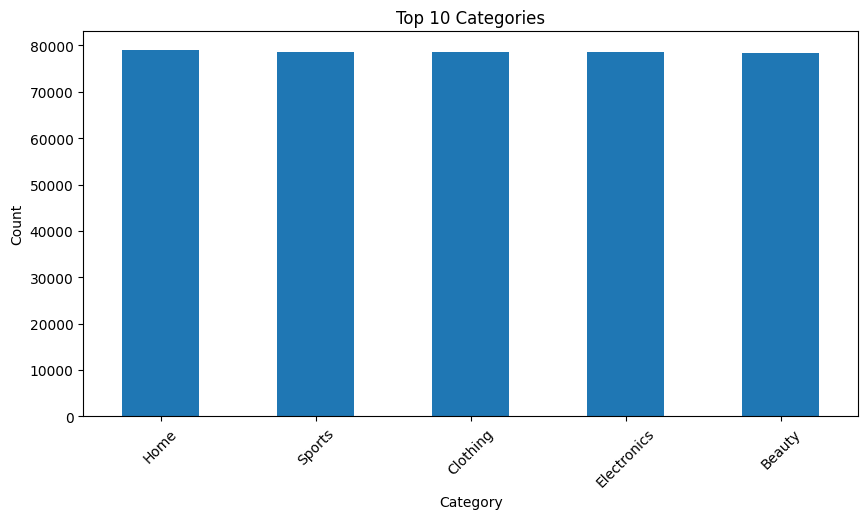

In [9]:
# DATA VISUALIZATION
# Top 10 Categories

plt.figure(figsize=(10,5))
df["category"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

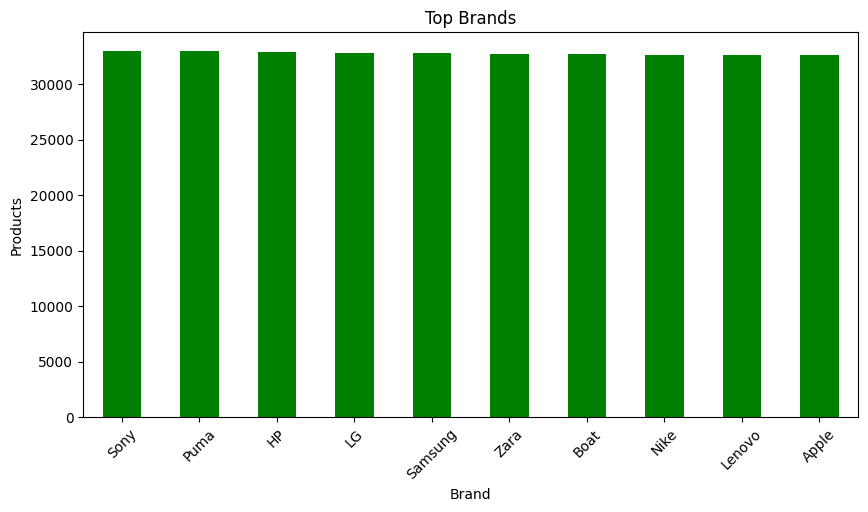

In [10]:
# Top Brands

plt.figure(figsize=(10,5))
df["brand"].value_counts().head(10).plot(kind="bar",color="green")
plt.title("Top Brands")
plt.xlabel("Brand")
plt.ylabel("Products")
plt.xticks(rotation=45)
plt.show()

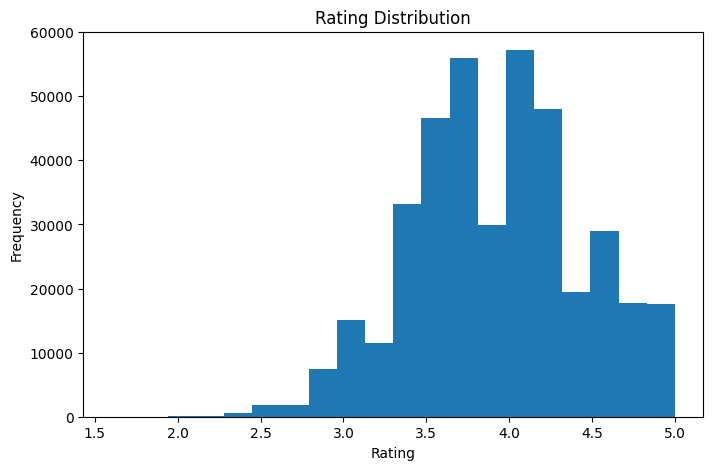

In [11]:
# Rating Distribution

plt.figure(figsize=(8,5))
plt.hist(df["rating"],bins=20)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

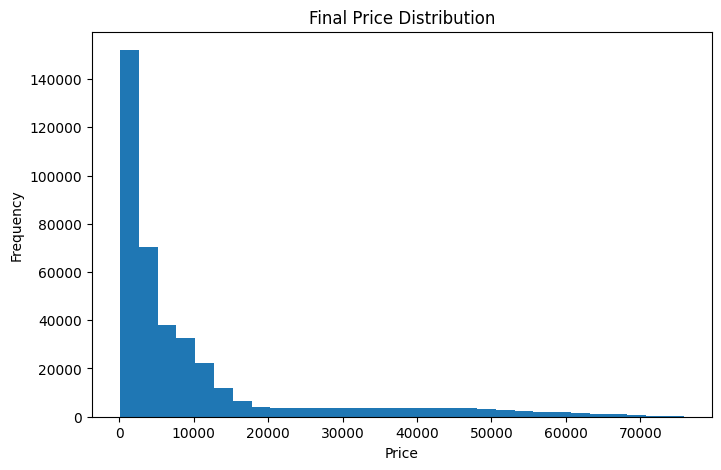

In [12]:
# Final Price Distribution

plt.figure(figsize=(8,5))
plt.hist(df["final_price"],bins=30)
plt.title("Final Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()


Correlation Matrix
                       price  discount  final_price    rating  review_count  \
price               1.000000 -0.208683     0.986276  0.331576      0.001092   
discount           -0.208683  1.000000    -0.291233 -0.071922      0.001660   
final_price         0.986276 -0.291233     1.000000  0.327258      0.000950   
rating              0.331576 -0.071922     0.327258  1.000000     -0.000928   
review_count        0.001092  0.001660     0.000950 -0.000928      1.000000   
stock               0.000843 -0.003021     0.000802 -0.000273      0.000264   
seller_rating      -0.000160  0.000854    -0.000107 -0.001263      0.000028   
shipping_time_days  0.000320 -0.000529     0.000538  0.001523      0.000362   

                       stock  seller_rating  shipping_time_days  
price               0.000843      -0.000160            0.000320  
discount           -0.003021       0.000854           -0.000529  
final_price         0.000802      -0.000107            0.000538  
rati

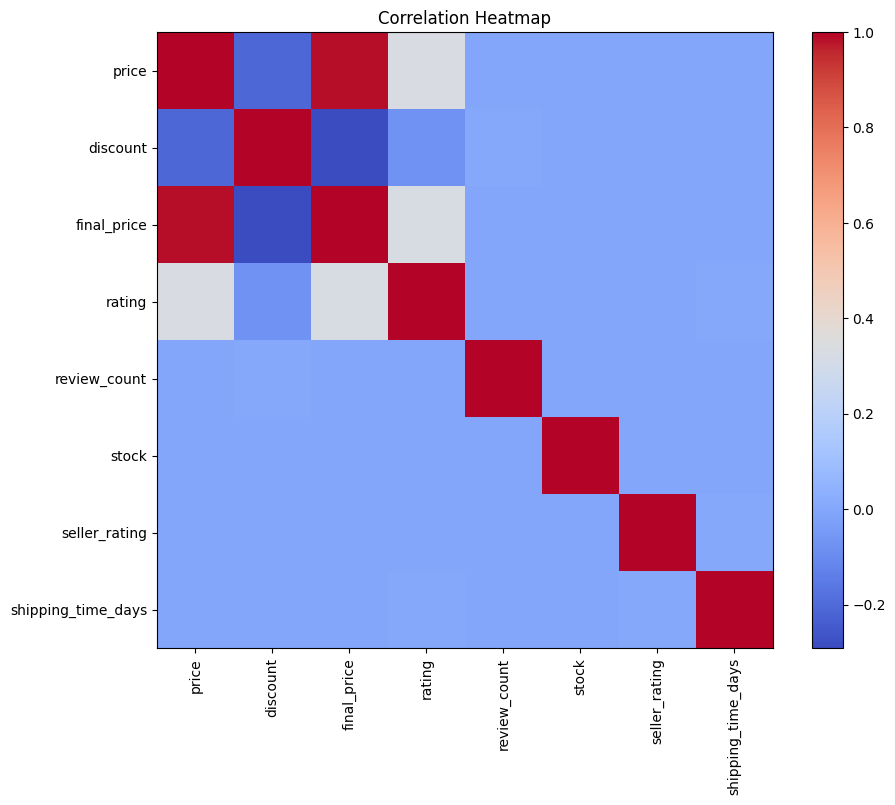

In [13]:
# CORRELATION ANALYSIS
correlation = df.select_dtypes(include=np.number).corr()

print("\nCorrelation Matrix")
print(correlation)

plt.figure(figsize=(10,8))
plt.imshow(correlation,cmap="coolwarm")
plt.colorbar()

plt.xticks(range(len(correlation.columns)),
           correlation.columns,
           rotation=90)
plt.yticks(range(len(correlation.columns)),
           correlation.columns)

plt.title("Correlation Heatmap")
plt.show()

In [14]:
# CUSTOMER SEGMENTATION
customer = df.groupby("user_id").agg({

    "final_price":"sum",
    "product_id":"count",
    "rating":"mean"

})

customer.columns=["Total_Spending",
                  "Total_Orders",
                  "Average_Rating"]

print("\nCustomer Segmentation")
print(customer.sort_values("Total_Spending",
                           ascending=False).head(10))


Customer Segmentation
         Total_Spending  Total_Orders  Average_Rating
user_id                                              
U757504       171141.83             3        4.533333
U309380       170998.53             5        4.240000
U913623       157487.61             4        3.900000
U522297       154960.70             3        4.100000
U612096       148545.55             3        4.966667
U426522       147713.08             4        4.075000
U495428       143421.13             6        3.983333
U445425       141237.53             4        4.600000
U125234       139937.59             5        4.040000
U323047       139657.36             4        3.850000


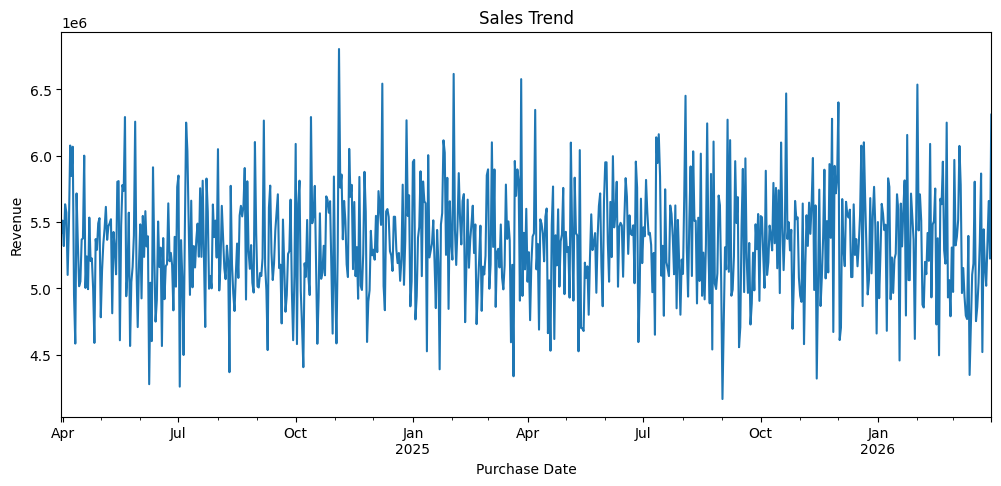

In [15]:
# SALES TREND ANALYSIS
sales = df.groupby("purchase_date")["final_price"].sum()

plt.figure(figsize=(12,5))
sales.plot()

plt.title("Sales Trend")
plt.xlabel("Purchase Date")
plt.ylabel("Revenue")
plt.show()


In [16]:
# TOP LOCATIONS
print("\nTop Locations")
print(df["location"].value_counts().head(10))


Top Locations
location
Delhi        78868
Bangalore    78782
Chennai      78653
Mumbai       78474
Hyderabad    78435
Unknown          1
Name: count, dtype: int64


In [17]:
# PAYMENT METHODS
print("\nPayment Methods")
print(df["payment_method"].value_counts())


Payment Methods
payment_method
UPI                 98720
Cash on Delivery    98418
Credit Card         98372
Debit Card          97702
Unknown                 1
Name: count, dtype: int64


In [18]:
# DELIVERY STATUS
print("\nDelivery Status")
print(df["delivery_status"].value_counts())


Delivery Status
delivery_status
Delayed       115991
In Transit    115739
Delivered     115672
Returned       45810
Unknown            1
Name: count, dtype: int64


In [19]:
# RETURNED PRODUCTS
print("\nReturned Products")
print(df["is_returned"].value_counts())

print("\nPROJECT COMPLETED SUCCESSFULLY")


Returned Products
is_returned
False      347402
True        45810
Unknown         1
Name: count, dtype: int64

PROJECT COMPLETED SUCCESSFULLY
